# NSL-KDD Intrusion Detection - Binary Classification (Normal vs Attack)
### Versi binary dari pipeline multi-class. Konsep pipeline tetap sama:
- Preprocessing (LabelEncoder per kolom, StandardScaler)
- **Elbow Method** untuk cari k optimal
- KMeans Cluster-Based Undersampling (k cluster, sample banyak per cluster)
- BorderlineSMOTE untuk minority class
- XGBoost classifier
- SHAP feature importance + retrain Top-N
- Hyperparameter tuning

**Strategi sampling:** target 65.000 per class (sama dengan versi UNSW)

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score

from imblearn.over_sampling import BorderlineSMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import shap
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [ ]:
train = pd.read_csv("kdd_train.csv", header=None)
test = pd.read_csv("kdd_test.csv", header=None)

columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label"
]

train.columns = columns
test.columns = columns

train = train.iloc[1:].copy()
test = test.iloc[1:].copy()

## 2. Binary Label Mapping
### CHANGE: label di-mapping ke binary -> 0 (Normal) atau 1 (Attack)
Semua label selain 'normal' dianggap attack.

In [ ]:
# Mapping binary: normal vs attack
def map_binary(label):
    if label == 'normal':
        return 0   # Normal
    else:
        return 1   # Attack (semua jenis: DoS, Probe, R2L, U2R, dll)

train['label'] = train['label'].apply(map_binary)
test['label']  = test['label'].apply(map_binary)

X_train = train.drop(columns=["label"])
y_train = train["label"]

X_test = test.drop(columns=["label"])
y_test = test["label"]

print("Train distribution:", Counter(y_train))
print("Test distribution :", Counter(y_test))
print("\n0 = Normal, 1 = Attack")

Train distribution: Counter({0: 67343, 1: 58630})
Test distribution : Counter({1: 11299, 0: 11245})

0 = Normal, 1 = Attack


## 3. Preprocessing
### LabelEncoder disimpan per kolom dalam dict agar tidak tertimpa

In [ ]:
categorical_cols = ["protocol_type", "service", "flag"]

# simpan setiap encoder dalam dict, bukan variabel tunggal yang ditimpa
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    # Handle unseen categories di test set
    X_test[col] = X_test[col].apply(
        lambda x: x if x in le.classes_ else le.classes_[0]
    )
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le  # simpan encoder per kolom

print("Categorical encoding done. Encoders saved:", list(label_encoders.keys()))

Categorical encoding done. Encoders saved: ['protocol_type', 'service', 'flag']


## 4. Scaling (Full Features)

In [ ]:
# Scaling - fit hanya dari X_train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Target binary - langsung pakai
y_train_bin = y_train.values
y_test_bin  = y_test.values

class_names = ['Normal', 'Attack']

print("Classes:", class_names)
print("X_train_scaled shape:", X_train_scaled.shape)
print("Class balance train:", Counter(y_train_bin))

Classes: ['Normal', 'Attack']
X_train_scaled shape: (125973, 41)
Class balance train: Counter({np.int64(0): 67343, np.int64(1): 58630})


## 5. Baseline: XGBoost tanpa Sampling (Unbalanced)

In [ ]:
print("Training baseline XGBoost (unbalanced)...")

# CHANGE: binary -> objective='binary:logistic', eval_metric='logloss'
model_xgb_unbalanced = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss', random_state=42, n_jobs=-1
)
model_xgb_unbalanced.fit(X_train_scaled, y_train_bin)
y_pred_unbalanced  = model_xgb_unbalanced.predict(X_test_scaled)
y_proba_unbalanced = model_xgb_unbalanced.predict_proba(X_test_scaled)[:, 1]

print("\n=== Baseline (Unbalanced) ===")
print(classification_report(y_test_bin, y_pred_unbalanced,
                             target_names=class_names))
print(f"ROC-AUC : {roc_auc_score(y_test_bin, y_proba_unbalanced):.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_test_bin, y_pred_unbalanced))

Training baseline XGBoost (unbalanced)...

=== Baseline (Unbalanced) ===
              precision    recall  f1-score   support

      Normal       0.90      0.99      0.94     11245
      Attack       0.99      0.89      0.94     11299

    accuracy                           0.94     22544
   macro avg       0.94      0.94      0.94     22544
weighted avg       0.94      0.94      0.94     22544

ROC-AUC : 0.9942
Confusion matrix:
[[11153    92]
 [ 1291 10008]]


## 6. Hybrid Sampling: KMeans Undersampling + BorderlineSMOTE
### Distribusi NSL-KDD KDDTrain+ (binary):
- Normal (0): ~67.343  → di-UNDERSAMPLE ke 65.000
- Attack (1): ~58.630  → di-SMOTE ke 65.000

**NEW:** Pakai elbow method untuk cari k optimal per class, lalu sample (target_n // k) sampel per cluster — sama persis dengan versi UNSW.

### 6.1 Elbow untuk class Normal (majority — yang akan di-undersample)

Jumlah sample class Normal (0): 67343


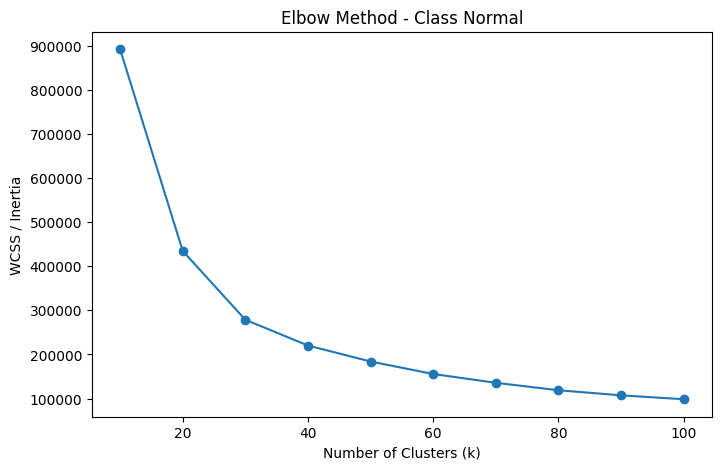

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []

k_range = range(10, 101, 10)

X_normal = X_train_scaled[y_train_bin == 0]

print(f"Jumlah sample class Normal (0): {len(X_normal)}")

for k in k_range:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_normal)

    inertia_values.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(k_range, inertia_values, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method - Class Normal")

plt.show()

### 6.3 KMeans Undersample function

In [ ]:
def kmeans_undersample(
    X,
    y,
    sampling_strategy,
    cluster_strategy,
    random_state=42
):

    X_result, y_result = [], []

    unique_classes = np.unique(y)

    rng = np.random.RandomState(random_state)

    for cls in unique_classes:

        # =====================================================
        # AMBIL DATA PER CLASS
        # =====================================================
        mask = (y == cls) if not hasattr(y, 'values') else (y.values == cls)

        X_cls = X[mask]

        # target jumlah setelah undersampling
        target_n = sampling_strategy.get(cls, len(X_cls))

        # jumlah cluster khusus tiap class
        n_cluster_cls = cluster_strategy.get(cls, 50)

        # =====================================================
        # MINORITY CLASS -> AMBIL SEMUA
        # =====================================================
        if len(X_cls) <= target_n:

            X_result.append(X_cls)
            y_result.extend([cls] * len(X_cls))

        # =====================================================
        # MAJORITY CLASS -> KMEANS CLUSTER SAMPLING
        # =====================================================
        else:

            print(f"\nClass : {cls}")
            print(f"Original samples : {len(X_cls)}")
            print(f"Target samples   : {target_n}")
            print(f"Clusters used    : {n_cluster_cls}")

            # KMeans clustering
            km = KMeans(
                n_clusters=n_cluster_cls,
                random_state=random_state,
                n_init=10,
                max_iter=300
            )

            cluster_labels = km.fit_predict(X_cls)

            # jumlah sampel yang diambil per cluster
            samples_per_cluster = target_n // n_cluster_cls

            selected_indices = []

            # =====================================================
            # SAMPLING TIAP CLUSTER
            # =====================================================
            for cluster_id in range(n_cluster_cls):

                cluster_idx = np.where(cluster_labels == cluster_id)[0]

                # jika isi cluster <= target per cluster
                if len(cluster_idx) <= samples_per_cluster:

                    selected_indices.extend(cluster_idx)

                else:

                    chosen = rng.choice(
                        cluster_idx,
                        size=samples_per_cluster,
                        replace=False
                    )

                    selected_indices.extend(chosen)

            selected_indices = np.array(selected_indices)

            # =====================================================
            # JIKA JUMLAH MASIH KURANG
            # =====================================================
            if len(selected_indices) < target_n:

                remaining = np.setdiff1d(
                    np.arange(len(X_cls)),
                    selected_indices
                )

                extra = rng.choice(
                    remaining,
                    size=target_n - len(selected_indices),
                    replace=False
                )

                selected_indices = np.concatenate([
                    selected_indices,
                    extra
                ])

            X_result.append(X_cls[selected_indices])

            y_result.extend([cls] * len(selected_indices))

    # =====================================================
    # GABUNGKAN SEMUA CLASS
    # =====================================================
    X_out = np.vstack(X_result)
    y_out = np.array(y_result)

    return X_out, y_out


In [ ]:
from collections import Counter
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from imblearn.over_sampling import BorderlineSMOTE

# =========================================================
# PARAMETER
# =========================================================

TARGET_PER_CLASS = 65000

# KMeans Undersampling (Normal = mayoritas)
sampling_strategy_under = {
    0: TARGET_PER_CLASS,
}

cluster_strategy = {
    0: 40,
}

# BorderlineSMOTE (Attack = minoritas)
sampling_strategy_smote = {
    1: TARGET_PER_CLASS,
}

experiments = {
    "Hybrid Sampling": "hybrid",
    "KMeans Only": "kmeans",
    "BorderlineSMOTE Only": "smote"
}

# =========================================================
# LOOP EKSPERIMEN
# =========================================================

for exp_name, exp_type in experiments.items():

    print("=" * 70)
    print(exp_name)
    print("=" * 70)

    # =====================================================
    # SAMPLING
    # =====================================================

    if exp_type == "hybrid":

        # Step 1 : KMeans Undersampling
        X_sample, y_sample = kmeans_undersample(
            X_train_scaled,
            y_train_bin,
            sampling_strategy=sampling_strategy_under,
            cluster_strategy=cluster_strategy,
            random_state=42
        )

        # Step 2 : BorderlineSMOTE
        smote = BorderlineSMOTE(
            kind='borderline-2',
            sampling_strategy=sampling_strategy_smote,
            k_neighbors=3,
            random_state=42
        )

        X_sample, y_sample = smote.fit_resample(
            X_sample,
            y_sample
        )

    elif exp_type == "kmeans":

        X_sample, y_sample = kmeans_undersample(
            X_train_scaled,
            y_train_bin,
            sampling_strategy=sampling_strategy_under,
            cluster_strategy=cluster_strategy,
            random_state=42
        )

    elif exp_type == "smote":

        smote = BorderlineSMOTE(
            kind='borderline-2',
            sampling_strategy=sampling_strategy_smote,
            k_neighbors=3,
            random_state=42
        )

        X_sample, y_sample = smote.fit_resample(
            X_train_scaled,
            y_train_bin
        )

    # =====================================================
    # DISTRIBUSI KELAS
    # =====================================================

    print("\nClass Distribution:")
    print(Counter(y_sample))

    # =====================================================
    # TRAIN XGBOOST
    # =====================================================

    model = XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_sample, y_sample)

    # =====================================================
    # PREDIKSI
    # =====================================================

    y_pred = model.predict(X_test_scaled)

    # =====================================================
    # HASIL
    # =====================================================

    print("\nClassification Report:")
    print(
        classification_report(
            y_test_bin,
            y_pred,
            target_names=["Normal", "Attack"]
        )
    )

Hybrid Sampling

Class : 0
Original samples : 67343
Target samples   : 65000
Clusters used    : 40

Class Distribution:
Counter({np.int64(0): 65000, np.int64(1): 65000})

Classification Report:
              precision    recall  f1-score   support

      Normal       0.90      0.99      0.94     11245
      Attack       0.99      0.89      0.93     11299

    accuracy                           0.94     22544
   macro avg       0.94      0.94      0.94     22544
weighted avg       0.94      0.94      0.94     22544

KMeans Only

Class : 0
Original samples : 67343
Target samples   : 65000
Clusters used    : 40

Class Distribution:
Counter({np.int64(0): 65000, np.int64(1): 58630})

Classification Report:
              precision    recall  f1-score   support

      Normal       0.89      0.99      0.94     11245
      Attack       0.99      0.88      0.93     11299

    accuracy                           0.94     22544
   macro avg       0.94      0.94      0.94     22544
weighted avg     